### Retail Demand & Inventory Analytics: Optimizing Inventory and Sales Performance

# Data Celaning 

In [1]:
import numpy as np 
import pandas as pd 

### Load a dataset retail_store_inventory.csv in df

In [6]:
df = pd.read_csv("../Dataset/retail_store_inventory.csv")

### Data Inspection

In [8]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


## Understanding a columns 
- inventory Level :- How much products are currently available in stock i.e available products 
- units Ordered :- more units orderd by store from seller
- Demand Forecast :- It shows how much demand or selling of that product
- Hoilday promotion :- when that product was sold was thier holiday if yes 1 if No 0
- Competitor Pricing:- price of same product in another store 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memory usage: 8.4+

## From info()
- i understood a rows and columns their are 73100 rows and 15 columns
- Their are all non-null values
- for all columns datatype is correct except
- Date column datatype is object i has to change it to Date

In [10]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [11]:
df.shape

(73100, 15)

#### Understood a shape datset have 731000 rows and 15 columns

In [12]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

### From isnull()
- No any null values are present in any columns

In [13]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

In [16]:
df[df.duplicated()].shape

(0, 15)

#### Duplicated
- no any duplicates are present

In [17]:
df["Store ID"].value_counts()

Store ID
S001    14620
S002    14620
S003    14620
S004    14620
S005    14620
Name: count, dtype: int64

In [18]:
df[df['Store ID'] == "S001"]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73015,2024-01-01,S001,P0016,Electronics,East,74,13,189,27.53,40.61,10,Cloudy,1,35.76,Summer
73016,2024-01-01,S001,P0017,Toys,East,282,186,61,201.40,20.68,0,Rainy,0,17.23,Winter
73017,2024-01-01,S001,P0018,Electronics,East,191,29,95,25.01,24.10,5,Cloudy,1,23.13,Winter
73018,2024-01-01,S001,P0019,Clothing,West,149,145,85,154.83,81.71,20,Sunny,0,80.86,Spring


In [19]:
df[df["Product ID"] == "P0001"]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
20,2022-01-01,S002,P0001,Groceries,South,343,104,144,112.55,32.80,20,Sunny,1,30.78,Spring
40,2022-01-01,S003,P0001,Toys,South,241,147,180,161.09,67.21,5,Sunny,1,67.39,Summer
60,2022-01-01,S004,P0001,Toys,South,477,271,66,286.65,15.62,15,Sunny,0,16.09,Winter
80,2022-01-01,S005,P0001,Toys,West,111,77,60,83.47,70.33,10,Cloudy,0,70.29,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73000,2024-01-01,S001,P0001,Toys,East,223,40,93,53.56,55.26,15,Rainy,0,59.37,Winter
73020,2024-01-01,S002,P0001,Clothing,East,415,18,67,27.20,11.72,15,Snowy,0,10.35,Spring
73040,2024-01-01,S003,P0001,Clothing,West,138,114,65,119.97,52.72,0,Sunny,0,52.90,Spring
73060,2024-01-01,S004,P0001,Electronics,East,497,496,137,489.62,42.34,15,Snowy,1,45.73,Spring


### For store ID and Product ID their will be duplucates present beacuse from one store many have buyed items.

### Validating Values for numerical cols

In [23]:
(df["Units Sold"] < 0).sum()

np.int64(0)

In [24]:
(df["Price"] < 0).sum()

np.int64(0)

In [25]:
(df["Inventory Level"] < 0).sum()

np.int64(0)

In [26]:
(df["Units Ordered"] < 0).sum()

np.int64(0)

In [27]:
(df["Demand Forecast"]< 0).sum()

np.int64(673)

In [28]:
(df["Discount"]< 0).sum()

np.int64(0)

In [29]:
(df["Competitor Pricing"]< 0).sum()

np.int64(0)

## All Nuerical COlumns are good their are  no any outliers

### Checking for unique values in categorical Columns

In [30]:
df["Category"].unique()

array(['Groceries', 'Toys', 'Electronics', 'Furniture', 'Clothing'],
      dtype=object)

In [32]:
df["Region"].unique()

array(['North', 'South', 'West', 'East'], dtype=object)

In [33]:
df["Weather Condition"].unique()

array(['Rainy', 'Sunny', 'Cloudy', 'Snowy'], dtype=object)

In [34]:
df["Seasonality"].unique()

array(['Autumn', 'Summer', 'Winter', 'Spring'], dtype=object)

In [40]:
df['Holiday/Promotion'].unique()

array([0, 1])

## All Good Categorical columns are all fine

## FInding Outliers

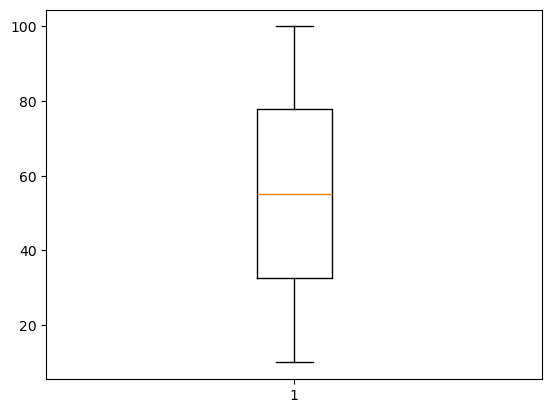

In [35]:
import matplotlib.pyplot as plt

plt.boxplot(df["Price"])
plt.show()

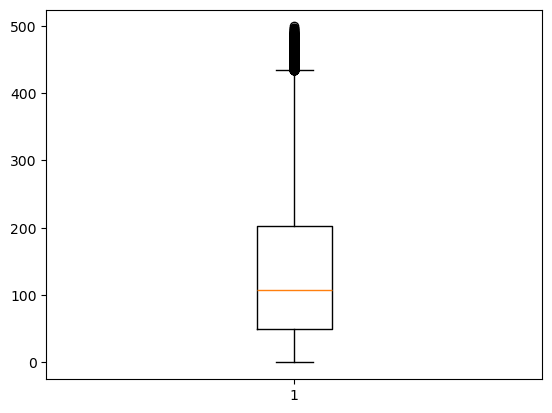

In [36]:
import matplotlib.pyplot as plt

plt.boxplot(df["Units Sold"])
plt.show()

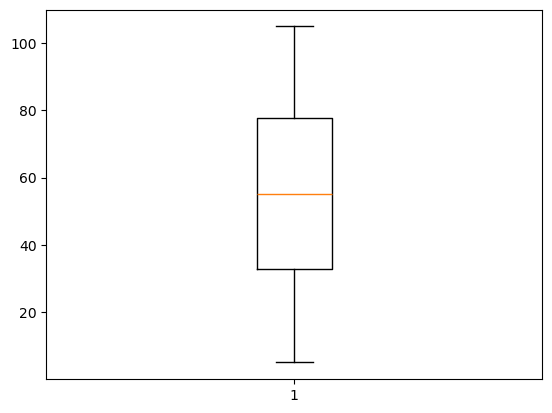

In [37]:
import matplotlib.pyplot as plt

plt.boxplot(df["Competitor Pricing"])
plt.show()

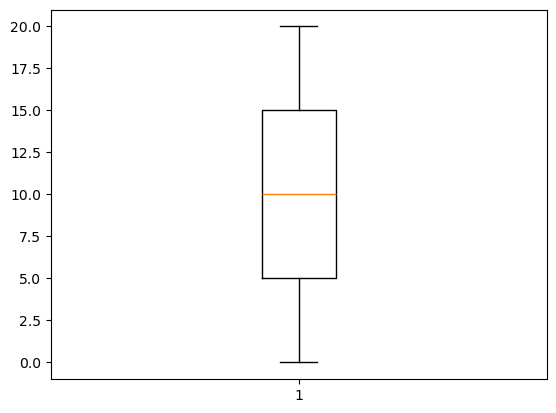

In [38]:
import matplotlib.pyplot as plt

plt.boxplot(df["Discount"])
plt.show()

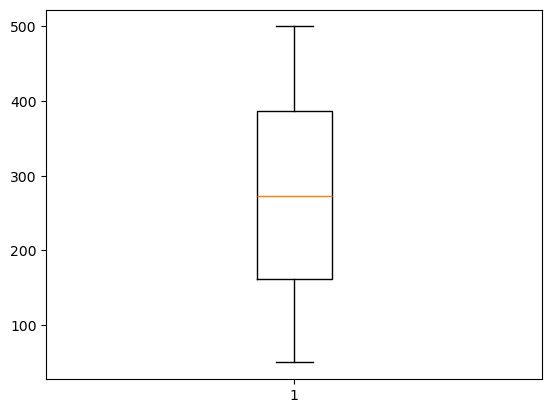

In [39]:
import matplotlib.pyplot as plt

plt.boxplot(df["Inventory Level"])
plt.show()

## NO any Outliers are present

## their NO missing values present so no need to fix missing values

## their are no duplicates present so no need to fix duplicates

## all formating are good so no need to fix inconsitent formating

### Correcting Datatype
- date have datatype object let change it to Date

In [43]:
df["Date"]

0        2022-01-01
1        2022-01-01
2        2022-01-01
3        2022-01-01
4        2022-01-01
            ...    
73095    2024-01-01
73096    2024-01-01
73097    2024-01-01
73098    2024-01-01
73099    2024-01-01
Name: Date, Length: 73100, dtype: object

In [44]:
df['Date'] = pd.to_datetime(df["Date"])

In [45]:
df["Date"]

0       2022-01-01
1       2022-01-01
2       2022-01-01
3       2022-01-01
4       2022-01-01
           ...    
73095   2024-01-01
73096   2024-01-01
73097   2024-01-01
73098   2024-01-01
73099   2024-01-01
Name: Date, Length: 73100, dtype: datetime64[ns]

### Feature Engineering

In [46]:
df["Revenue"] = df["Units Sold"] * df["Price"]

In [47]:
df["Month"] = df["Date"].dt.month_name()

In [48]:
df["Year"] = df["Date"].dt.year

In [49]:
df["Quarter"] = df["Date"].dt.quarter

### DATA CLEANING COMPLETED 

In [50]:
df.head(5)

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Revenue,Month,Year,Quarter
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,4254.50,January,2022,1
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,9451.50,January,2022,1
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,1819.35,January,2022,1
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,1995.92,January,2022,1
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,1030.96,January,2022,1


In [52]:
df.to_csv("../Dataset/retail_store_inventory_cleaned.csv", index=False)

## Stored a Cleaned Data set file in Dataset FOlder

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   